## 1. Import libraries & packages

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

## 2. Load training data source into a dataframe & perform basic data checks

In [2]:
df = pd.read_csv("data/raw/train.csv")
df.head()

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


#### 2.1 Shape of dataset

In [3]:
print(f"No. of rows: {df.shape[0]}")
print(f"No. of columns: {df.shape[1]}")

No. of rows: 439140
No. of columns: 16


#### 2.2 Schema of dataset

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      439140 non-null  int64  
 1   Driver                  439140 non-null  str    
 2   Compound                439140 non-null  str    
 3   Race                    439140 non-null  str    
 4   Year                    439140 non-null  int64  
 5   PitStop                 439140 non-null  int64  
 6   LapNumber               439140 non-null  int64  
 7   Stint                   439140 non-null  int64  
 8   TyreLife                439140 non-null  float64
 9   Position                439140 non-null  int64  
 10  LapTime (s)             439140 non-null  float64
 11  LapTime_Delta           439140 non-null  float64
 12  Cumulative_Degradation  439140 non-null  float64
 13  RaceProgress            439140 non-null  float64
 14  Position_Change         439140 

#### 2.3 Check for Null values

In [5]:
df.isnull().sum()

id                        0
Driver                    0
Compound                  0
Race                      0
Year                      0
PitStop                   0
LapNumber                 0
Stint                     0
TyreLife                  0
Position                  0
LapTime (s)               0
LapTime_Delta             0
Cumulative_Degradation    0
RaceProgress              0
Position_Change           0
PitNextLap                0
dtype: int64

#### 2.4 Check for duplicate rows

In [6]:
print(f"No of duplicate rows: {df.duplicated().sum()}")

No of duplicate rows: 0


In [7]:
df.describe()

,id,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
count,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000
mean,219569.500000,2023.523544,0.136118,23.105909,1.789113,14.158231,9.630339,90.948735,-3.770040,-25.721759,0.337661,0.101542,0.198982
std,126768.942943,1.024930,0.342915,16.958261,0.950194,9.801338,5.278770,19.772769,43.945759,54.766573,0.253277,4.006765,0.399235
min,0.000000,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.694000,-2403.895000,-274.564000,0.012821,-18.000000,0.000000
25%,109784.750000,2023.000000,0.000000,9.000000,1.000000,6.000000,5.000000,82.621000,-8.884000,-46.566250,0.129870,-1.000000,0.000000
50%,219569.500000,2024.000000,0.000000,19.000000,2.000000,12.000000,10.000000,90.521000,-0.295000,-20.994000,0.269231,0.000000,0.000000
75%,329354.250000,2024.000000,0.000000,36.000000,2.000000,20.000000,14.000000,98.471000,0.115000,-6.199000,0.513158,2.000000,0.000000
max,439139.000000,2025.000000,1.000000,78.000000,8.000000,77.000000,20.000000,2507.607000,2423.932000,2412.026000,1.000000,18.000000,1.000000


# 3. Class imbalance check

PitNextLap
0.0    0.801018
1.0    0.198982
Name: proportion, dtype: float64


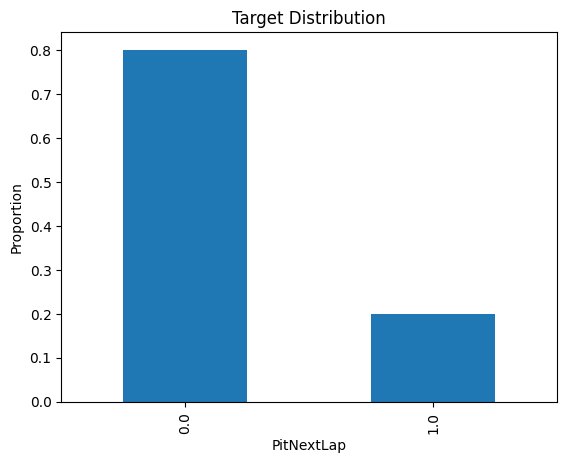

In [8]:
balance = df['PitNextLap'].value_counts(normalize=True)
print(balance)

# Visualize it
balance.plot(kind='bar', title='Target Distribution')
plt.ylabel('Proportion')
plt.show()

# 4. Identifying Numerical & Nominal attributes

Since some columns are nominal in nature but are forced to be numerical due to their datatypes, therefore appending those columns to this list before plotting

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      439140 non-null  int64  
 1   Driver                  439140 non-null  str    
 2   Compound                439140 non-null  str    
 3   Race                    439140 non-null  str    
 4   Year                    439140 non-null  int64  
 5   PitStop                 439140 non-null  int64  
 6   LapNumber               439140 non-null  int64  
 7   Stint                   439140 non-null  int64  
 8   TyreLife                439140 non-null  float64
 9   Position                439140 non-null  int64  
 10  LapTime (s)             439140 non-null  float64
 11  LapTime_Delta           439140 non-null  float64
 12  Cumulative_Degradation  439140 non-null  float64
 13  RaceProgress            439140 non-null  float64
 14  Position_Change         439140 

In [10]:
categorial_cols = []
numerical_cols = []

all_columns = df.columns.to_list()
for cols in all_columns:

    # check for object, category and bool datatype
    if (df[cols].nunique() <= 10) or (df[cols].dtype) =="str":
        categorial_cols.append(cols)
    
    # left over true numerical cols
    else:
        numerical_cols.append(cols)

print(categorial_cols)
print(numerical_cols)

['Driver', 'Compound', 'Race', 'Year', 'PitStop', 'Stint', 'PitNextLap']
['id', 'LapNumber', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change']


# 5. Univariate Analysis

#### 5.1 Plot the count distribution of categorical columns having less than 10 unique values

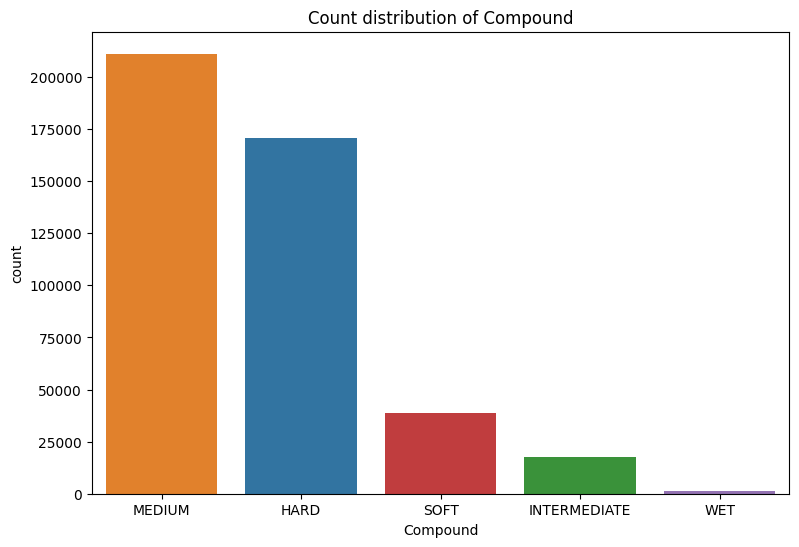

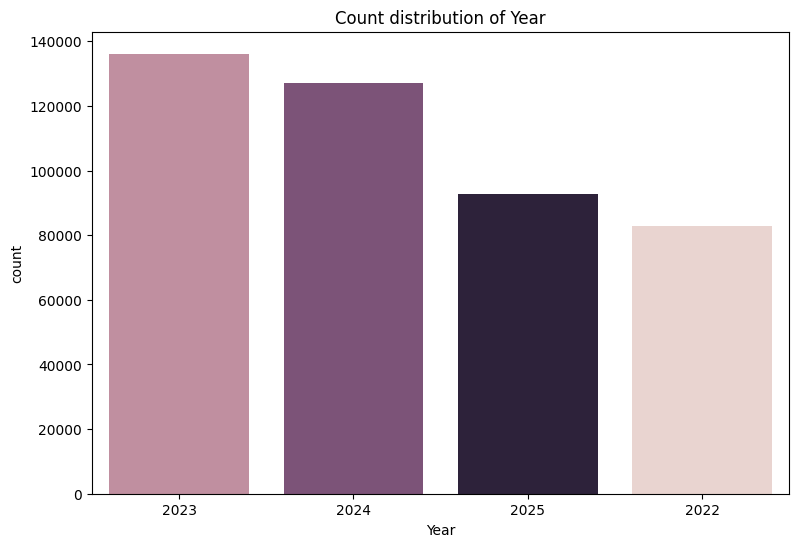

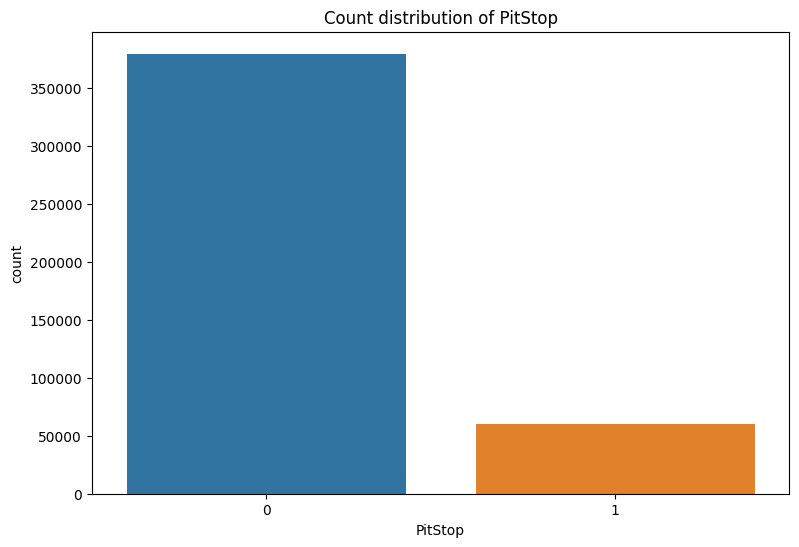

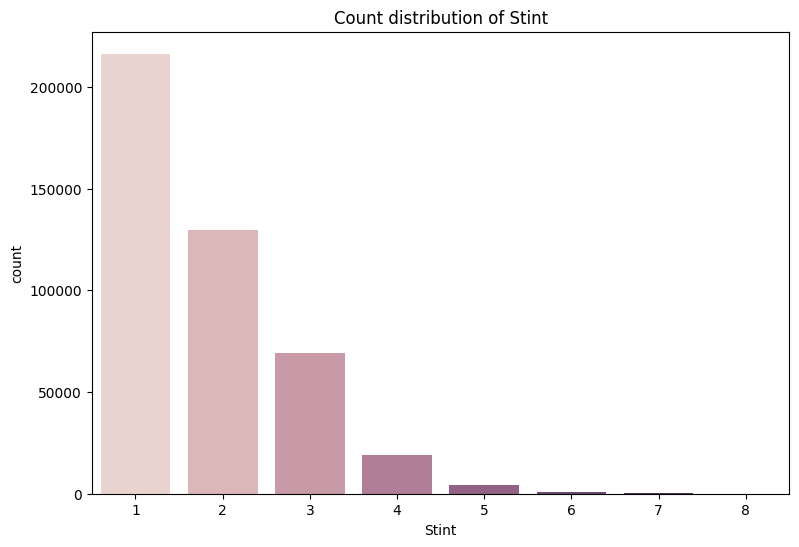

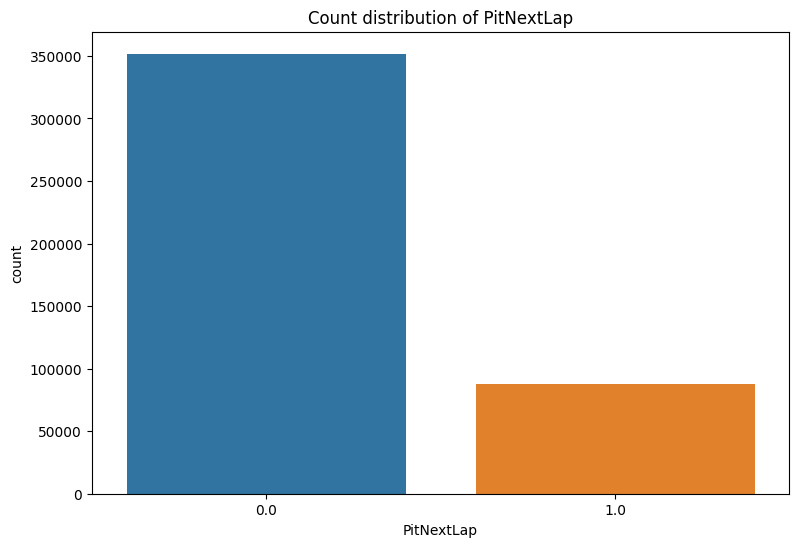

In [12]:
for cols in categorial_cols:
    if (df[cols].nunique() <= 10):
        order = df[cols].value_counts().sort_values(ascending=False).index
        plt.figure(figsize=(9,6))
        plt.title(f"Count distribution of {cols}")
        sb.countplot(data=df, x = cols, hue = cols, order = order, legend=False)
        plt.show()

#### 5.2 Plot the count and density distribution of numerical columns along with descriptive analysis

**5.2.1 LapNumber** – Lap index within the race

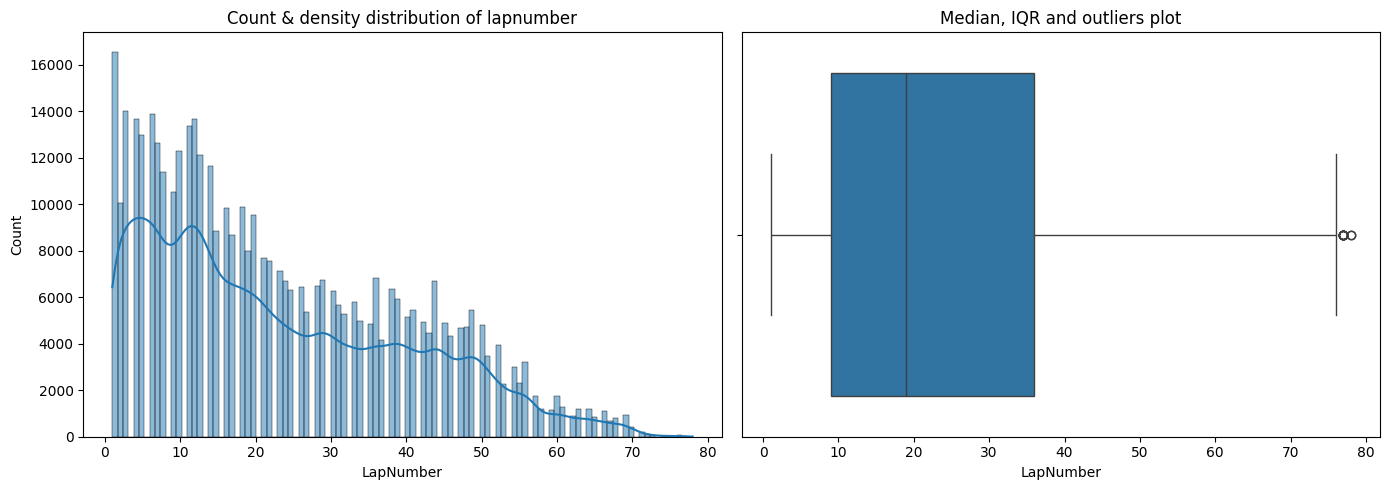

In [13]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

sb.histplot(data=df,x="LapNumber",kde=True,ax = axes[0])
axes[0].set_title("Count & density distribution of lapnumber")

# second plot
sb.boxplot(data=df, x='LapNumber', ax=axes[1])
axes[1].set_title("Median, IQR and outliers plot")

plt.tight_layout()
plt.show()

- Majority of the data points belong to early Lap ranges (1-20)
- The distribution plot signifies the data set is right skewed as the tail strecthes towards higher lap numbers
- Since the median is shifted towards the left inside the Boxplot, it confirms the dataset is right skewed.
- There are only two dots beyond whiskeres, indicating outliers towards high lap numbers.
- IQR = Q3 - Q1 = 35 - 10 = 25
- Lower Bound = 10 - 1.5×25 = -27.5 → effectively 0 (no lower outliers)
- Upper Bound = 35 + 1.5×25 = 72.5 → anything above ~72 is an outlier

**Observations:**

- LapNumber ranges from approximately 2 to 80
- Median is around Lap 20, meaning more than half the pit-related events occur in the first half of the race
- Q1 ≈ 10, Q3 ≈ 35 → 50% of all data sits between Lap 10 and Lap 35
- The box is shifted towards the left, confirming right skew (consistent with KDE finding)
- Two outlier points exist near Lap 77-80 — very late race laps are rare in this dataset

**5.2.2 TyreLife** – Number of laps on current tire

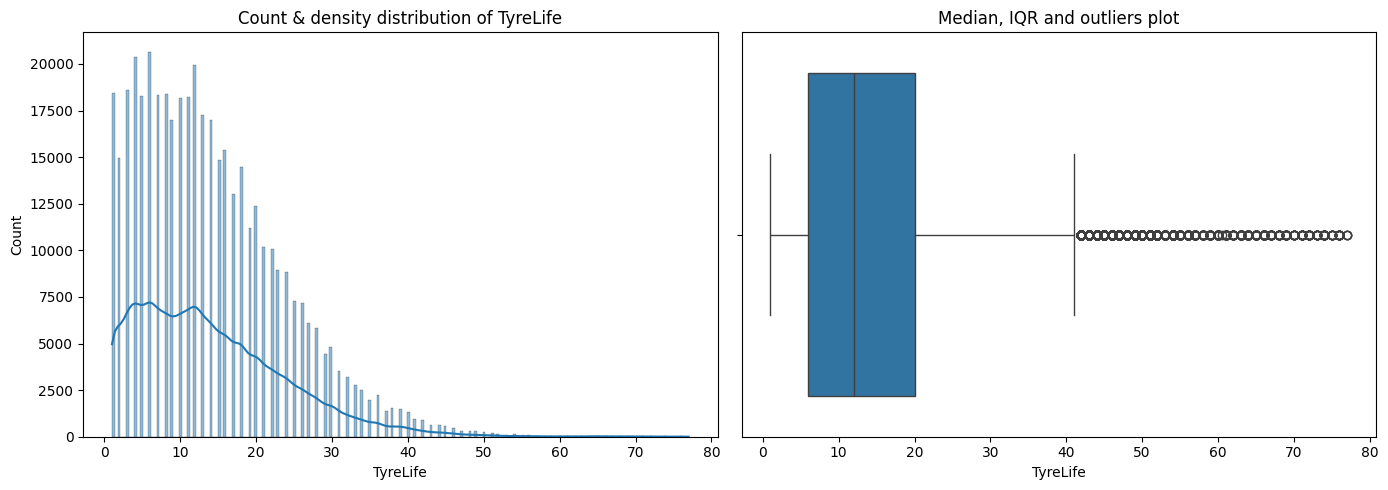

In [15]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

sb.histplot(data=df,x="TyreLife",kde=True,ax = axes[0])
axes[0].set_title("Count & density distribution of TyreLife")

# second plot
sb.boxplot(data=df, x='TyreLife', ax=axes[1])
axes[1].set_title("Median, IQR and outliers plot")

plt.tight_layout()
plt.show()

* IQR = Q3 - Q1 = 20 - 8 = 12
* Lower Bound = 8 - 1.5×12 = -10 → effectively 0 (no lower outliers)
* Upper Bound = 20 + 1.5×12 = 38 → anything above ~38-42 is an outlier

* TyreLife ranges from 0 to ~78 laps but majority of data is concentrated in 0–40 range
* Median tyre age is approximately Lap 13, meaning half the pit/race observations happen before tyre completes 13 laps
* Q1 ≈ 8, Q3 ≈ 20 → 50% of all tyre usage falls between Lap 8 and Lap 20
* Distribution is heavily right-skewed — most tyres are used for fewer laps, very few tyres run extremely long
* Bimodal KDE with two peaks at ~5 and ~11 suggests two distinct tyre usage patterns in the dataset
* Large number of outliers on the right side (Lap 43–78) — these represent unusually long tyre stints

**5.2.3 Position** – Driver’s position on that lap

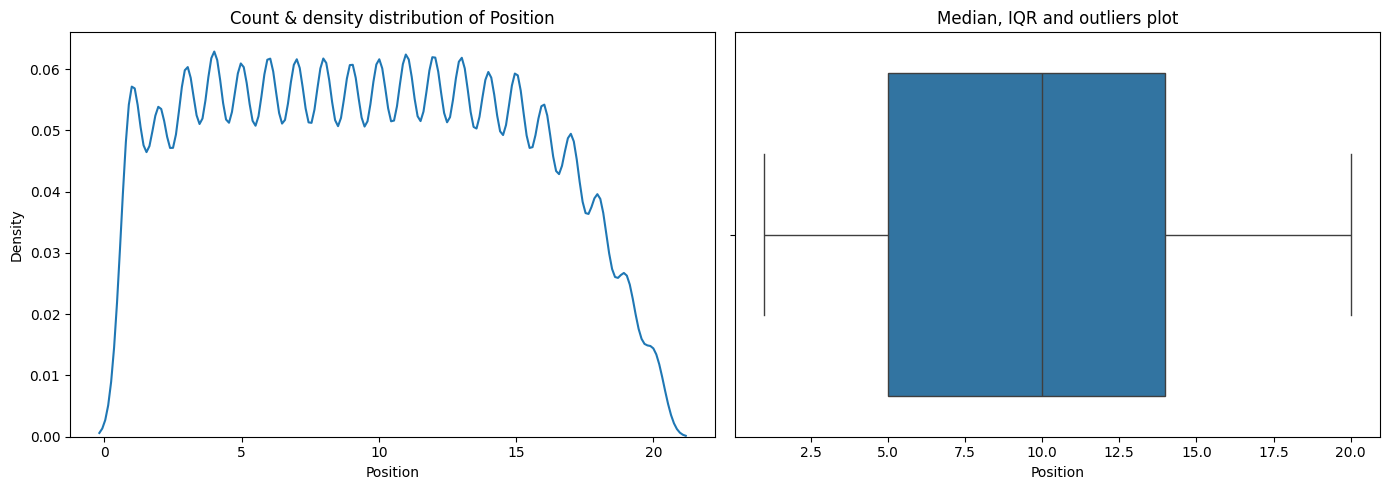

In [17]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

sb.kdeplot(data=df,x="Position",ax = axes[0])
axes[0].set_title("Count & density distribution of Position")

# second plot
sb.boxplot(data=df, x='Position', ax=axes[1])
axes[1].set_title("Median, IQR and outliers plot")

plt.tight_layout()
plt.show()

* Uniform mid-range dominance: The driver spends most of their lap between positions 1 and 17, with nearly equal time across that range — typical of a track with consistent sector speeds (no single very slow or very fast zone dominating).
* Oscillating density peaks: The rapid oscillations in the KDE are a strong signal of repeated passes through the same position coordinates, consistent with a looped circuit. Each "wave" likely represents one lap cycle.
* No outliers: The box plot whiskers reach almost exactly to the distribution extremes with no isolated points, meaning the driver's position data is clean and consistent — no pit lane excursions or anomalous laps skewing the data.
* Slight right-skew in the tail: The density drops more gradually after position 17, suggesting the driver decelerates or spends slightly less time in the higher-position zone (possibly a braking or hairpin section near the end of the measured segment).

**5.2.4 LapTime(s)** – Lap time in seconds

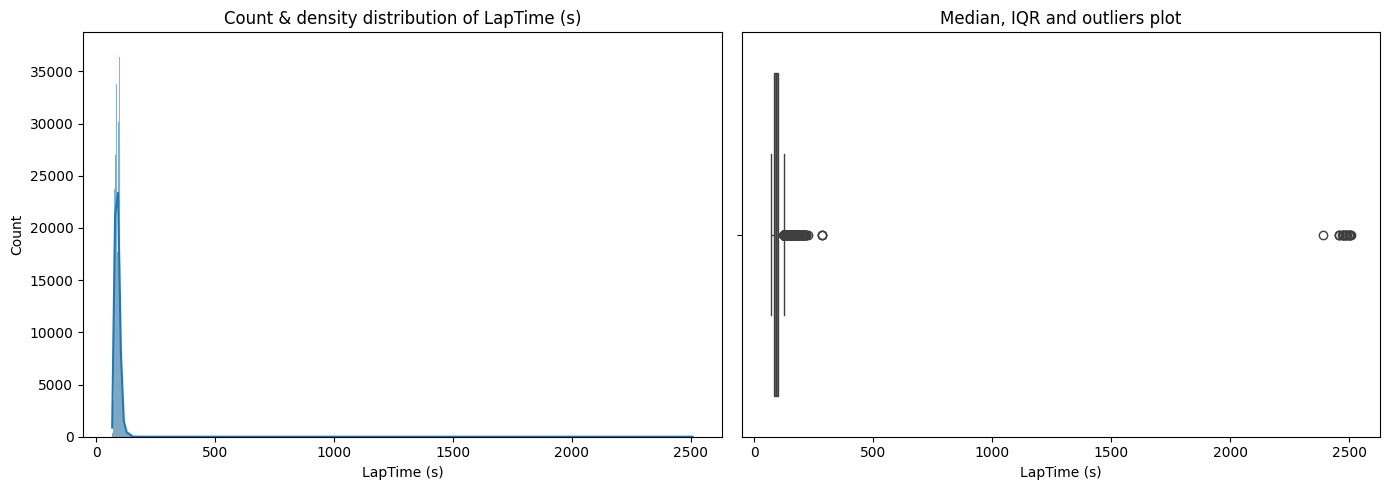

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

sb.histplot(data=df,x="LapTime (s)",kde=True,ax = axes[0])
axes[0].set_title("Count & density distribution of LapTime (s)")

# second plot
sb.boxplot(data=df, x='LapTime (s)', ax=axes[1])
axes[1].set_title("Median, IQR and outliers plot")

plt.tight_layout()
plt.show()

- **Heavily right-skewed distribution**: The vast majority of lap times cluster tightly
  between ~50s and ~300s, with a sharp peak count exceeding 35,000 near ~80–100s,
  indicating this is the typical competitive lap time range.

- **Median lap time ≈ 100s**: The median sits around 100 seconds, consistent with a
  short-to-medium length circuit. The IQR spans roughly 50s–200s.

- **Long right tail**: A small number of laps extend beyond 300s up to ~1300s,
  representing slow laps likely caused by pit stops, safety car periods, formation
  laps, or in-laps/out-laps.

- **Significant outliers at 1300s–2500s**: The box plot reveals a distinct cluster of
  outliers in the 2400–2500s range, along with a few isolated points near 1300s.
  These likely correspond to red flag stoppages, virtual safety car periods, or
  heavily delayed laps where the car was stationary or parked.

- **Near-zero lap times present**: The whisker on the box plot extends close to 0,
  suggesting some records with very small lap time values exist — these may be data
  artefacts, sensor noise, or incomplete lap recordings and should be filtered before
  modelling.

- **Recommendation**: Apply a lap time filter (e.g., keep only laps between 60s–300s)
  to remove anomalous entries before any performance or predictive analysis.

**5.2.5 LapTime_Delta** – Change in lap time from previous lap

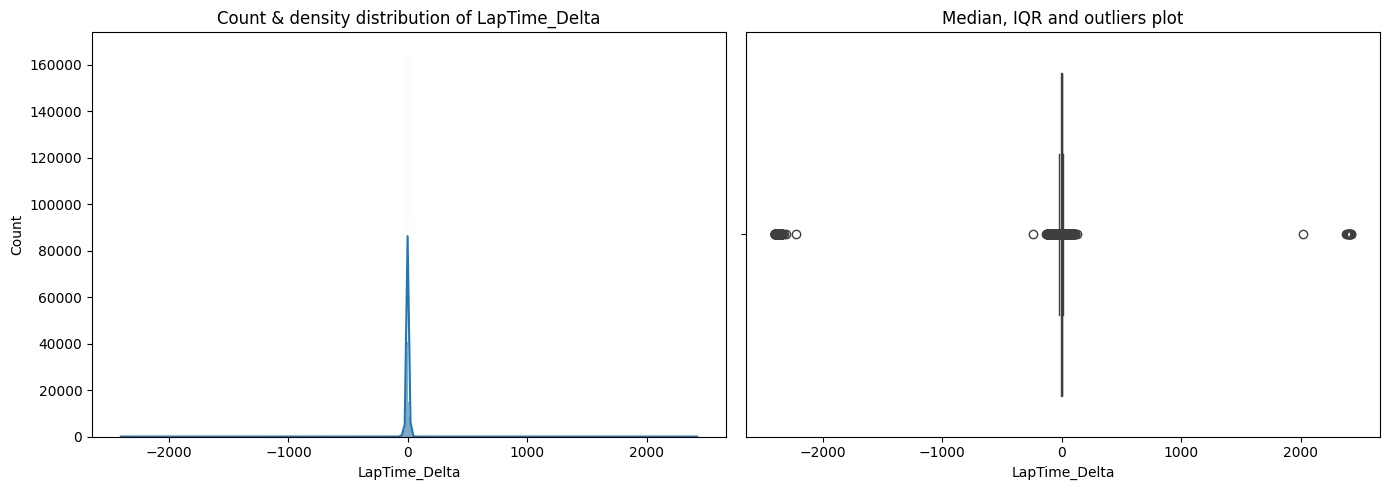

In [19]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

sb.histplot(data=df,x="LapTime_Delta",kde=True,ax = axes[0])
axes[0].set_title("Count & density distribution of LapTime_Delta")

# second plot
sb.boxplot(data=df, x='LapTime_Delta', ax=axes[1])
axes[1].set_title("Median, IQR and outliers plot")

plt.tight_layout()
plt.show()

- **Extremely tight distribution around 0**: Nearly all values fall within a very narrow
  band near zero, with a peak count of ~85,000, meaning most lap-to-lap time changes
  are negligible — the driver is highly consistent.

- **Symmetric shape**: The distribution is roughly symmetric around 0, indicating no
  systematic tendency to get faster or slower across laps.

- **Extreme outliers on both sides**: The box plot shows dense outlier clusters at
  approximately ±2000–2500s, almost certainly caused by the anomalous lap times
  identified in the previous LapTime analysis (red flags, stoppages). These deltas
  are artefacts, not real performance swings.

- **Recommendation**: Filter LapTime_Delta alongside LapTime — removing anomalous laps
  will eliminate these extreme delta values automatically.

**5.2.6 Cumulative_Degradation** – Accumulated tire performance drop

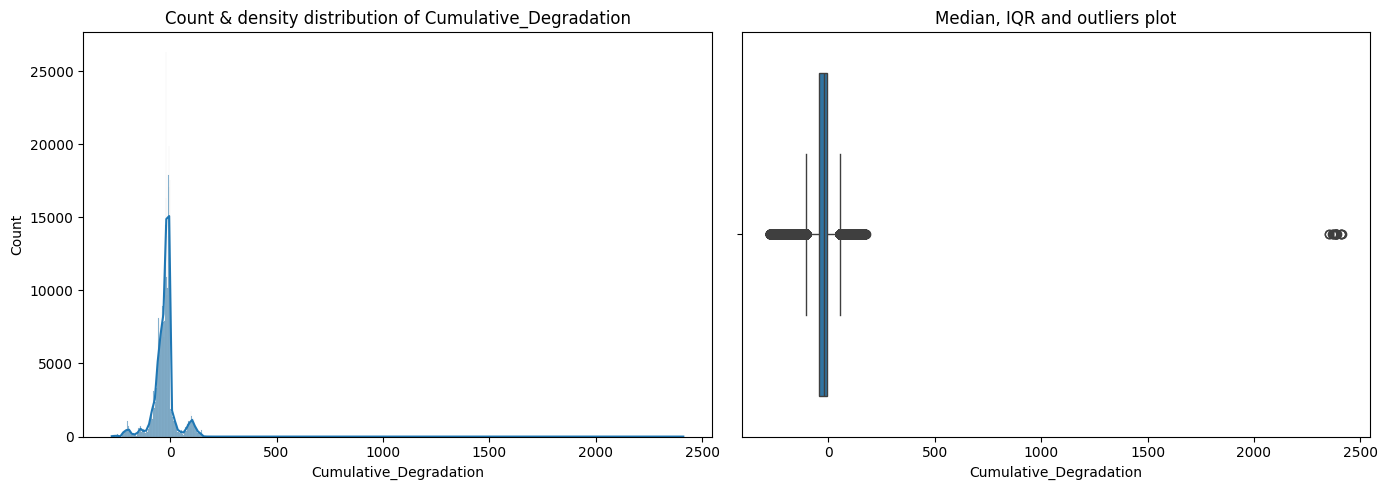

In [21]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

sb.histplot(data=df,x="Cumulative_Degradation",kde=True,ax = axes[0])
axes[0].set_title("Count & density distribution of Cumulative_Degradation")

# second plot
sb.boxplot(data=df, x='Cumulative_Degradation', ax=axes[1])
axes[1].set_title("Median, IQR and outliers plot")

plt.tight_layout()
plt.show()

- **Concentrated near zero with slight right skew**: Most values cluster tightly around
  0–100, with two noticeable peaks near 0 and ~50, suggesting two dominant degradation
  states (fresh tyres vs. moderate wear).

- **Median ≈ 0, wide IQR**: The median sits very close to zero with the IQR spanning
  roughly –300 to +200, indicating high variability in how degradation accumulates
  across laps/stints.

- **Negative values present**: Some records show negative cumulative degradation, likely
  caused by tyre changes resetting the counter or data artefacts — worth investigating
  before modelling.

- **Outliers at ~2300–2400**: A small dense cluster of extreme outliers exists at the
  far right, consistent with the anomalous long-duration laps seen in LapTime and
  LapTime_Delta — likely the same red flag / stoppage events propagating through
  derived features.

- **Recommendation**: Align degradation filtering with the LapTime filter (60s–300s
  window) to remove artefact-driven outliers, and investigate the source of negative
  degradation values before using this feature in any predictive model.

**5.2.7 RaceProgress** – Fraction of race completed (0 → 1)

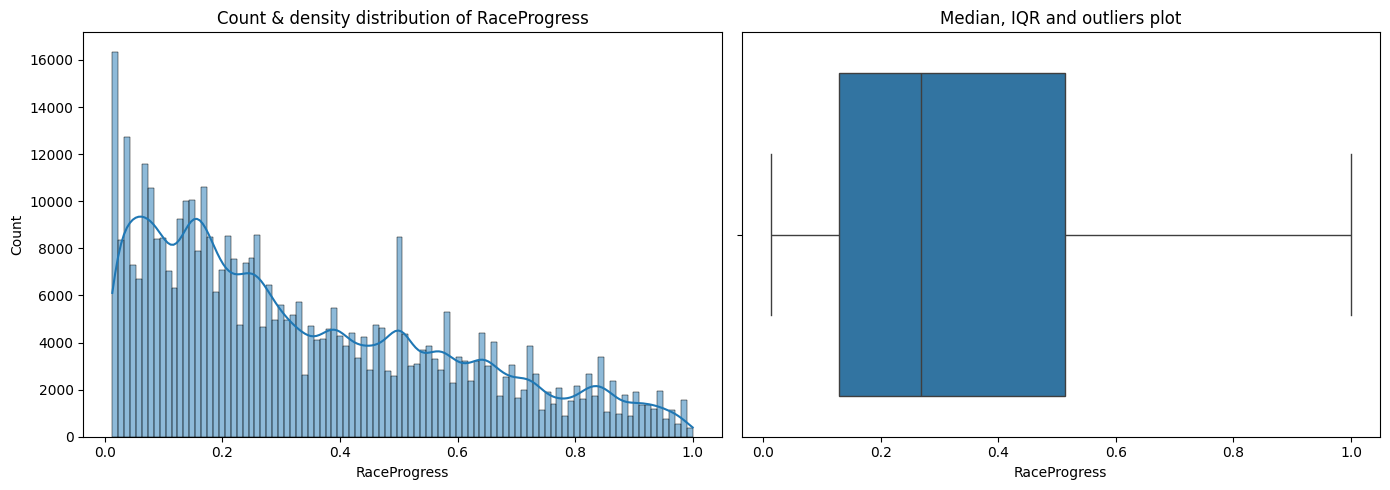

In [22]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

sb.histplot(data=df,x="RaceProgress",kde=True,ax = axes[0])
axes[0].set_title("Count & density distribution of RaceProgress")

# second plot
sb.boxplot(data=df, x='RaceProgress', ax=axes[1])
axes[1].set_title("Median, IQR and outliers plot")

plt.tight_layout()
plt.show()

- **Strong early-race bias**: The distribution peaks sharply near 0.0–0.05, with counts
  exceeding 16,000, indicating far more data points recorded at the start of races —
  likely due to retirements, DNFs, or more cars in early laps.

- **Gradual decay with a mid-race bump**: Count steadily declines from ~0.2 onward, but
  a secondary bump around 0.15–0.20 suggests a structural feature (e.g. pit stop
  window or safety car period) consistently occurring at that race stage.

- **Median ≈ 0.28, IQR ~0.15–0.55**: The middle 50% of records fall in the first half
  of the race, confirming the left-skewed nature of the data.

- **Full range 0.0–1.0, no outliers**: Whiskers extend cleanly to both extremes with no
  outliers — the feature is well-bounded and needs no clipping.

- **Recommendation**: The heavy early-race weighting may bias time-series or
  progress-dependent models; consider stratified sampling or weighting by RaceProgress
  to ensure balanced representation across the full race duration.

**5.2.8 Position_Change** – Position gain/loss compared to previous lap

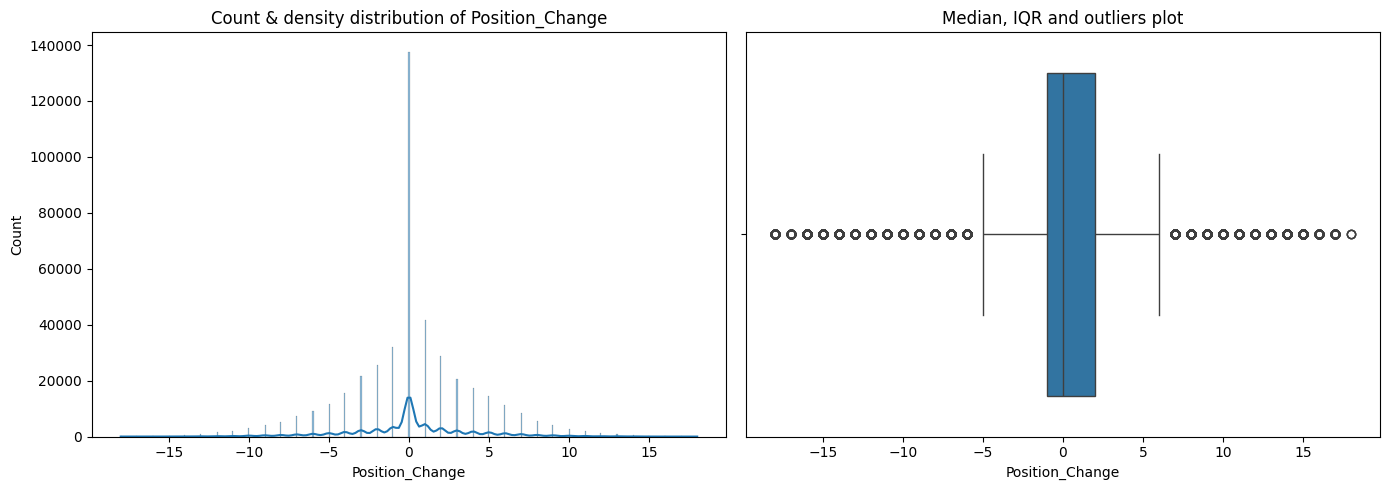

In [23]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

sb.histplot(data=df,x="Position_Change",kde=True,ax = axes[0])
axes[0].set_title("Count & density distribution of Position_Change")

# second plot
sb.boxplot(data=df, x='Position_Change', ax=axes[1])
axes[1].set_title("Median, IQR and outliers plot")

plt.tight_layout()
plt.show()

- **Strongly peaked at 0**: The dominant spike at 0 (count ~140,000) shows that in most
  laps, the driver holds their position — no overtake or place change occurs.

- **Discrete integer distribution**: The comb-like pattern of isolated spikes confirms
  Position_Change is a whole-number variable (positions gained/lost are always integers).

- **Roughly symmetric around 0**: Gains and losses are similarly distributed, suggesting
  no systematic bias toward gaining or losing positions across the dataset.

- **IQR spans approximately –5 to +2**: The middle 50% of changes are small, with the
  median sitting at 0, reflecting the generally stable nature of race positions
  lap-to-lap.

- **Heavy outliers on both sides (±8 to ±18)**: The box plot shows numerous outlier
  circles extending to roughly ±18, representing large position swings — likely caused
  by pit stops, safety car restarts, first-lap chaos, or retirements of competitors.

- **Recommendation**: Consider capping or binning extreme Position_Change values (e.g.,
  beyond ±10) for modelling, as these edge cases are rare events that may introduce
  noise rather than learnable signal.